In [ ]:
# from huggingface_hub import notebook_login
# notebook_login()

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
from datasets import load_dataset

tool_call_dataset = load_dataset("glaiveai/glaive-function-calling-v2")

README.md:   0%|          | 0.00/106 [00:00<?, ?B/s]

glaive-function-calling-v2.json:   0%|          | 0.00/271M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/112960 [00:00<?, ? examples/s]

In [ ]:
tool_call_dataset

DatasetDict({
    train: Dataset({
        features: ['system', 'chat'],
        num_rows: 112960
    })
})

In [ ]:
print(tool_call_dataset['train'][101]['chat'])

USER: Hi, I need to convert 500 US dollars to Euros. Can you help me with that?


ASSISTANT: <functioncall> {"name": "convert_currency", "arguments": '{"amount": 500, "from_currency": "USD", "to_currency": "EUR"}'} <|endoftext|>


FUNCTION RESPONSE: {"converted_amount": 425.50, "from_currency": "USD", "to_currency": "EUR"}


ASSISTANT: Sure, 500 US dollars is approximately 425.50 Euros. <|endoftext|>





In [ ]:
def count_user_assistant_turns(chats):
    user_turn = 0
    assistant_turn = 0
    function_responses = 0
    for chat in chats:
        if chat.strip().startswith('USER:'):
            user_turn += 1
        elif chat.strip().startswith('ASSISTANT:'):
            assistant_turn += 1
        elif chat.strip().startswith('FUNCTION RESPONSE:'):
            function_responses += 1

    return user_turn, assistant_turn, function_responses

In [ ]:
def irrelevant_function_provided(chats):
    for chat in chats:
        if chat.strip().startswith("ASSISTANT: I'm sorry") or chat.strip().startswith("ASSISTANT: I am sorry"):
            return True

    return False

In [ ]:
# Prompt Types
no_function_prompt = []
function_prompt = []
function_with_multi_user_turn_prompt = []
irrelevant_function_prompt = []
with_function_response_prompt = []

def process_dataset(dataset):
    for row in dataset:
        system_instructions = row['system']
        chat = row['chat']

        if system_instructions.strip() == 'SYSTEM: You are a helpful assistant, with no access to external functions.':
            user_agent_responses = []
            chats = chat.split('\n')
            user_agent_responses.append(chats[0])
            user_agent_responses.append(
                'ASSISTANT: I am a Function calling model, so you will have to provide me with some external function. <|endoftext|>'
            )
            finalized_prompt = system_instructions + '\n\n' + '\n'.join(user_agent_responses)
            no_function_prompt.append(finalized_prompt)
        else:
            chats = chat.split('\n')
            user_turn, assistant_turn, function_responses = count_user_assistant_turns(chats)
            if user_turn > 1 and assistant_turn > 1 and function_responses == 0:
                function_with_multi_user_turn_prompt.append(
                    system_instructions + '\n\n' + '\n'.join([chat for chat in chats if chat.strip()])
                )
            elif user_turn == 1 and assistant_turn == 1 and function_responses == 0:
                if irrelevant_function_provided(chats):
                    irrelevant_function_prompt.append(
                        system_instructions + '\n\n' + '\n'.join([chat for chat in chats if chat.strip()])
                    )
                else:
                    function_prompt.append(
                        system_instructions + '\n\n' + '\n'.join([chat for chat in chats if chat.strip()])
                    )
            elif function_responses > 0:
                with_function_response_prompt.append(
                    system_instructions + '\n\n' + '\n'.join([chat for chat in chats if chat.strip()])
                )

In [ ]:
process_dataset(tool_call_dataset['train'])

In [ ]:
print(f"""
Total: {len(tool_call_dataset['train'])}
Function Prompt: {len(function_prompt)}
No Function Prompt: {len(no_function_prompt)}
Multi User Turn Prompt: {len(function_with_multi_user_turn_prompt)}
Irrelevant Function Prompt: {len(irrelevant_function_prompt)}
With Function Response Prompt: {len(with_function_response_prompt)}
""")


Total: 112960
Function Prompt: 0
No Function Prompt: 34598
Multi User Turn Prompt: 11
Irrelevant Function Prompt: 14975
With Function Response Prompt: 63376



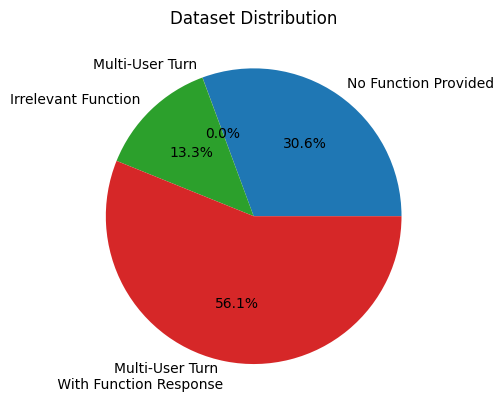

In [ ]:
import matplotlib.pyplot as plt

# Data to plot
labels = ['No Function Provided', 'Multi-User Turn', 'Irrelevant Function', 'Multi-User Turn \n With Function Response']
sizes = [
    len(no_function_prompt), len(function_with_multi_user_turn_prompt), len(irrelevant_function_prompt), len(with_function_response_prompt)
]

# Create the pie chart
plt.pie(sizes, labels=labels, autopct='%1.1f%%',)
plt.title("Dataset Distribution")
plt.show()

In [ ]:
from datasets import DatasetDict, Dataset

no_function_prompt_dataset = Dataset.from_dict(
    {'prompt': [prompt for prompt in no_function_prompt]}
)
multi_user_turn_prompt_dataset = Dataset.from_dict(
    {'prompt': [prompt for prompt in function_with_multi_user_turn_prompt]}
)
irrelevant_function_prompt_dataset = Dataset.from_dict(
    {'prompt': [prompt for prompt in irrelevant_function_prompt]}
)
with_function_response_prompt_dataset = Dataset.from_dict(
    {'prompt': [prompt for prompt in with_function_response_prompt]}
)

In [ ]:
transformed_dataset = DatasetDict(
    {
        'no_function': no_function_prompt_dataset,
        'multi_user_turn': multi_user_turn_prompt_dataset,
        'irrelevant_function': irrelevant_function_prompt_dataset,
        'with_function_response': with_function_response_prompt_dataset,
    }
)

In [ ]:
transformed_dataset

DatasetDict({
    no_function: Dataset({
        features: ['prompt'],
        num_rows: 34598
    })
    multi_user_turn: Dataset({
        features: ['prompt'],
        num_rows: 11
    })
    irrelevant_function: Dataset({
        features: ['prompt'],
        num_rows: 14975
    })
    with_function_response: Dataset({
        features: ['prompt'],
        num_rows: 63376
    })
})

In [ ]:
# 20,000 prompts from "with_function_response"
# 5,000 prompts from "irrelevant_function"
# 11 prompts from "multi_user_turn"
# 5,000 prompts from "no_function"

prepared_train_prompts = []
prepared_train_prompts.extend(transformed_dataset['with_function_response']['prompt'][:50000])
prepared_train_prompts.extend(transformed_dataset['irrelevant_function']['prompt'][:2000])
prepared_train_prompts.extend(transformed_dataset['multi_user_turn']['prompt'][:11])
prepared_train_prompts.extend(transformed_dataset['no_function']['prompt'][:2000])

In [ ]:
len(prepared_train_prompts)

54011

In [ ]:
print(prepared_train_prompts[2001])

SYSTEM: You are a helpful assistant with access to the following functions. Use them if required -
{
    "name": "generate_random_color",
    "description": "Generate a random color",
    "parameters": {
        "type": "object",
        "properties": {},
        "required": []
    }
}


USER: I'm working on a design project and I need some inspiration. Can you suggest a random color for me?
ASSISTANT: <functioncall> {"name": "generate_random_color", "arguments": {}} <|endoftext|>
FUNCTION RESPONSE: {"color": "#7B68EE"}
ASSISTANT: Sure, how about trying the color with the code #7B68EE? It's a shade of blue, specifically medium slate blue. It might add a nice touch to your design project. <|endoftext|>


In [ ]:
import random

random.shuffle(prepared_train_prompts)

In [ ]:
print(prepared_train_prompts[2001])

SYSTEM: You are a helpful assistant with access to the following functions. Use them if required -
{
    "name": "generate_random_password",
    "description": "Generate a random password with a specified length and complexity",
    "parameters": {
        "type": "object",
        "properties": {
            "length": {
                "type": "integer",
                "description": "The length of the password"
            },
            "complexity": {
                "type": "string",
                "enum": [
                    "low",
                    "medium",
                    "high"
                ],
                "description": "The complexity level of the password"
            }
        },
        "required": [
            "length",
            "complexity"
        ]
    }
}


USER: Hi, I need a new password. Can you generate one for me?
ASSISTANT: Of course, I can help with that. How long would you like your password to be and what level of complexity do you prefer

In [ ]:
from transformers import AutoTokenizer

gemma_270m = 'google/gemma-3-270m'
tokenizer = AutoTokenizer.from_pretrained(gemma_270m)

config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

In [ ]:
# Running method in parallel and hence processing individual elements.
def format_and_tokenize_single_dataset(dataset_split):
    tokenized_dataset = tokenizer.encode(dataset_split)
    return tokenized_dataset

In [ ]:
from joblib import Parallel, delayed
from tqdm.auto import tqdm

tasks = (delayed(format_and_tokenize_single_dataset)(row) for row in prepared_train_prompts)

# Run in parallel
tokenized_dataset = list(tqdm(
    Parallel(n_jobs=-1, return_as="generator", batch_size=3000)(tasks),
    total=len(prepared_train_prompts),
    desc="Tokenizing"
))

Tokenizing:   0%|          | 0/54011 [00:00<?, ?it/s]

In [ ]:
print(tokenizer.decode(tokenized_dataset[9000]))

<bos>SYSTEM: You are a helpful assistant with access to the following functions. Use them if required -
{
    "name": "get_stock_price",
    "description": "Get the current stock price",
    "parameters": {
        "type": "object",
        "properties": {
            "symbol": {
                "type": "string",
                "description": "The stock symbol e.g. AAPL"
            }
        },
        "required": [
            "symbol"
        ]
    }
}


USER: Hi, can you tell me the current stock price of Apple?
ASSISTANT: <functioncall> {"name": "get_stock_price", "arguments": '{"symbol": "AAPL"}'} <|endoftext|>
FUNCTION RESPONSE: {"status": "success", "data": {"symbol": "AAPL", "price": 150.75}}
ASSISTANT: The current stock price of Apple (AAPL) is $150.75. <|endoftext|>
USER: That's great! Can you also tell me the current stock price of Microsoft?
ASSISTANT: <functioncall> {"name": "get_stock_price", "arguments": '{"symbol": "MSFT"}'} <|endoftext|>
FUNCTION RESPONSE: {"status":

In [ ]:
print(tokenized_dataset[101])

[2, 90846, 236787, 1599, 659, 496, 11045, 16326, 607, 2802, 531, 506, 2269, 5151, 236761, 6890, 1091, 768, 3149, 753, 107, 236782, 107, 140, 236775, 1201, 1083, 623, 2305, 236779, 17133, 827, 107, 140, 236775, 7777, 1083, 623, 8980, 573, 6249, 2721, 580, 3260, 236764, 3822, 236764, 653, 18355, 827, 107, 140, 236775, 19031, 1083, 642, 107, 144, 236775, 2084, 1083, 623, 5973, 827, 107, 144, 236775, 15921, 1083, 642, 107, 148, 236775, 3278, 1083, 642, 107, 152, 236775, 2084, 1083, 623, 2383, 827, 107, 152, 236775, 7777, 1083, 623, 818, 3927, 7609, 236775, 107, 148, 1263, 107, 148, 236775, 6386, 1083, 642, 107, 152, 236775, 2084, 1083, 623, 2383, 827, 107, 152, 236775, 7777, 1083, 623, 818, 3260, 531, 5957, 506, 3927, 236775, 107, 148, 1263, 107, 148, 236775, 3250, 1083, 642, 107, 152, 236775, 2084, 1083, 623, 2383, 827, 107, 152, 236775, 7777, 1083, 623, 818, 3822, 531, 5957, 506, 3927, 236775, 107, 148, 1263, 107, 148, 236775, 56036, 1083, 642, 107, 152, 236775, 2084, 1083, 623, 2383, 82

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class FunctionCallDataset(Dataset):
    def __init__(self, tokenized_list):
        self.data = tokenized_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long, device=device)

In [ ]:
function_call_dataset = FunctionCallDataset(tokenized_dataset)

In [ ]:
len(function_call_dataset.data)

54011

In [ ]:
tokenizer.pad_token_id, tokenizer.eos_token_id, tokenizer.bos_token_id

(0, 1, 2)

In [ ]:
tokenizer.decode(tokenizer.pad_token_id)

'<pad>'

In [ ]:
tokenizer.vocab_size

262144

In [ ]:
def dynamic_collate_fn(batch):
    pad_token_id = tokenizer.pad_token_id

    # 1. Pad the sequences so they all match the longest one in this batch
    padded_input_ids = pad_sequence(batch, batch_first=True, padding_value=pad_token_id)

    # 2. For Causal LM, labels are a direct copy of the input_ids
    labels = padded_input_ids.clone()

    # 3. Dynamically create the attention mask
    # It creates a tensor of 1s where the token is real, and 0s where it is padding
    attention_masks = (padded_input_ids != pad_token_id).long()

    # 4. Replace padding token ids in labels with -100 to ignore them in loss calculation
    labels[labels == pad_token_id] = -100

    # 3. Return the neat dictionary that standard NLP models expect
    return {
        'input_ids': padded_input_ids,
        'attention_mask': attention_masks,
        'labels': labels
    }

In [ ]:
train_dataloader = DataLoader(
    function_call_dataset,
    batch_size=1,
    shuffle=True,
    collate_fn=dynamic_collate_fn
)

In [ ]:
first_batch = next(iter(train_dataloader))

In [ ]:
first_batch['input_ids'].shape, first_batch['attention_mask'].shape, first_batch['labels'].shape

(torch.Size([1, 693]), torch.Size([1, 693]), torch.Size([1, 693]))

In [ ]:
print(tokenizer.decode(first_batch['input_ids'].tolist()[0]))

<bos>SYSTEM: You are a helpful assistant with access to the following functions. Use them if required -
{
    "name": "generate_invoice",
    "description": "Generate an invoice for a product or service",
    "parameters": {
        "type": "object",
        "properties": {
            "customer_name": {
                "type": "string",
                "description": "The name of the customer"
            },
            "product_name": {
                "type": "string",
                "description": "The name of the product or service"
            },
            "quantity": {
                "type": "integer",
                "description": "The quantity of the product or service"
            },
            "price": {
                "type": "number",
                "description": "The price per unit of the product or service"
            }
        },
        "required": [
            "customer_name",
            "product_name",
            "quantity",
            "price"
        ]

In [ ]:
from torch.optim import AdamW
from transformers import get_scheduler
from transformers import AutoTokenizer, AutoModelForCausalLM

# Standard learning rate for fine-tuning
learning_rate = 5e-5
num_epochs = 1

# Load model from hugging face
model_id = 'google/gemma-3-270m'
pretrained_model = AutoModelForCausalLM.from_pretrained(model_id)

optimizer = AdamW(pretrained_model.parameters(), lr=learning_rate)

# Calculate total training steps
num_training_steps = num_epochs * len(function_call_dataset)

# Set up the learning rate scheduler
lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

model.safetensors:   0%|          | 0.00/536M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/133 [00:00<?, ?B/s]

In [ ]:
pretrained_model.to(device)

Gemma3ForCausalLM(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 640, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): Linear(in_features=640, out_features=1024, bias=False)
          (k_proj): Linear(in_features=640, out_features=256, bias=False)
          (v_proj): Linear(in_features=640, out_features=256, bias=False)
          (o_proj): Linear(in_features=1024, out_features=640, bias=False)
          (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
          (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
        )
        (mlp): Gemma3MLP(
          (gate_proj): Linear(in_features=640, out_features=2048, bias=False)
          (up_proj): Linear(in_features=640, out_features=2048, bias=False)
          (down_proj): Linear(in_features=2048, out_features=640, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma3RMSNorm((640,), eps=1e-06)

In [ ]:
from tqdm.auto import tqdm
import statistics

progress_bar = tqdm(range(num_training_steps), desc="Training")
pretrained_model.train() # Put model in training mode

losses = []
loss_log_interval = 500
losses_in_interval = []

for epoch in range(num_epochs):
    for batch in train_dataloader:
        # if batch['input_ids'].shape[1] > 511:
        #     continue

        # Move all tensors in the batch to the designated device
        batch = {k: v for k, v in batch.items()}
        # print(batch)

        # 1. Forward pass
        outputs = pretrained_model(**batch)
        loss = outputs.loss
        losses_in_interval.append(loss.item())

        if (len(losses) % loss_log_interval) == 0:
          print(f"Loss after {len(losses)} steps: {statistics.mean(losses_in_interval):.4f}")
          losses_in_interval = []

        # 2. Backward pass
        loss.backward()
        losses.append(loss)

        # 3. Update weights and learning rate
        optimizer.step()
        lr_scheduler.step()

        # 4. Clear gradients for the next step
        optimizer.zero_grad()

        # Update progress bar and print loss
        progress_bar.update(1)
        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})


Training:   0%|          | 0/54011 [00:00<?, ?it/s]

Loss after 0 steps: 1.3288
Loss after 500 steps: 0.3798
Loss after 1000 steps: 0.2600
Loss after 1500 steps: 0.2496
Loss after 2000 steps: 0.2139
Loss after 2500 steps: 0.2250
Loss after 3000 steps: 0.1991
Loss after 3500 steps: 0.2044
Loss after 4000 steps: 0.1982
Loss after 4500 steps: 0.1759
Loss after 5000 steps: 0.1824
Loss after 5500 steps: 0.1737
Loss after 6000 steps: 0.1698
Loss after 6500 steps: 0.1760
Loss after 7000 steps: 0.1631
Loss after 7500 steps: 0.1686
Loss after 8000 steps: 0.1450
Loss after 8500 steps: 0.1709
Loss after 9000 steps: 0.1539
Loss after 9500 steps: 0.1642
Loss after 10000 steps: 0.1547
Loss after 10500 steps: 0.1524
Loss after 11000 steps: 0.1579
Loss after 11500 steps: 0.1598
Loss after 12000 steps: 0.1661
Loss after 12500 steps: 0.1346
Loss after 13000 steps: 0.1482
Loss after 13500 steps: 0.1534
Loss after 14000 steps: 0.1524
Loss after 14500 steps: 0.1430
Loss after 15000 steps: 0.1333
Loss after 15500 steps: 0.1427
Loss after 16000 steps: 0.1536
L

KeyboardInterrupt: 

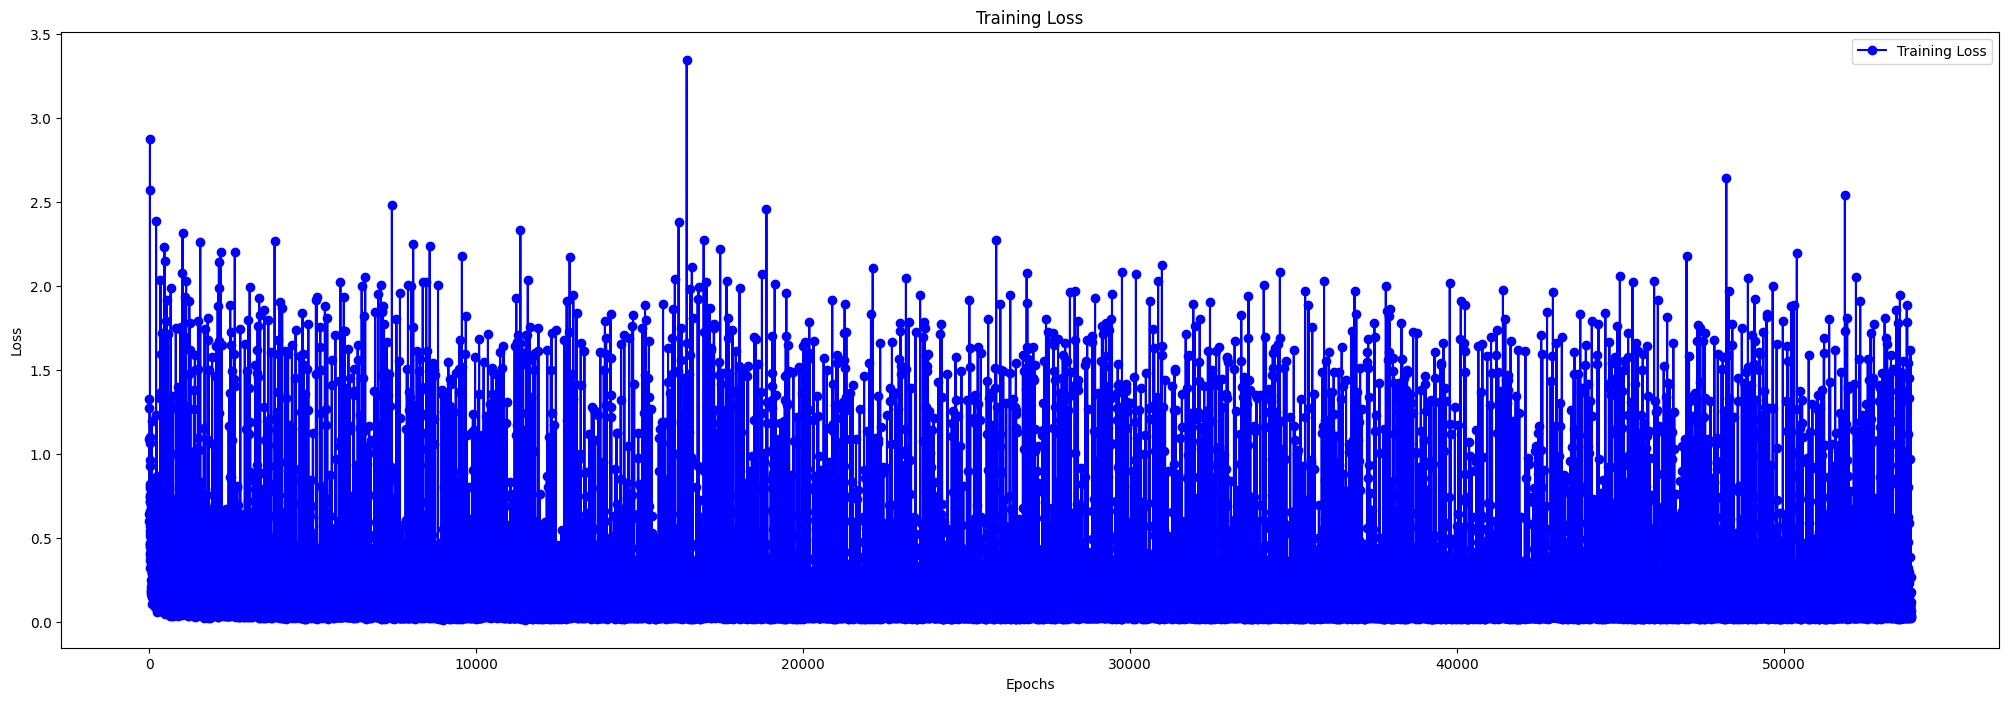

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 8))

# Plotting
plt.plot([(i+1) for i, loss in enumerate(losses)], [loss.item() for loss in losses], 'bo-', label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
avg_losses = []
cur_losses = []

for loss in losses:
    cur_losses.append(loss.item())
    if len(cur_losses) == 500:
        avg_losses.append(statistics.mean(cur_losses))
        cur_losses = []

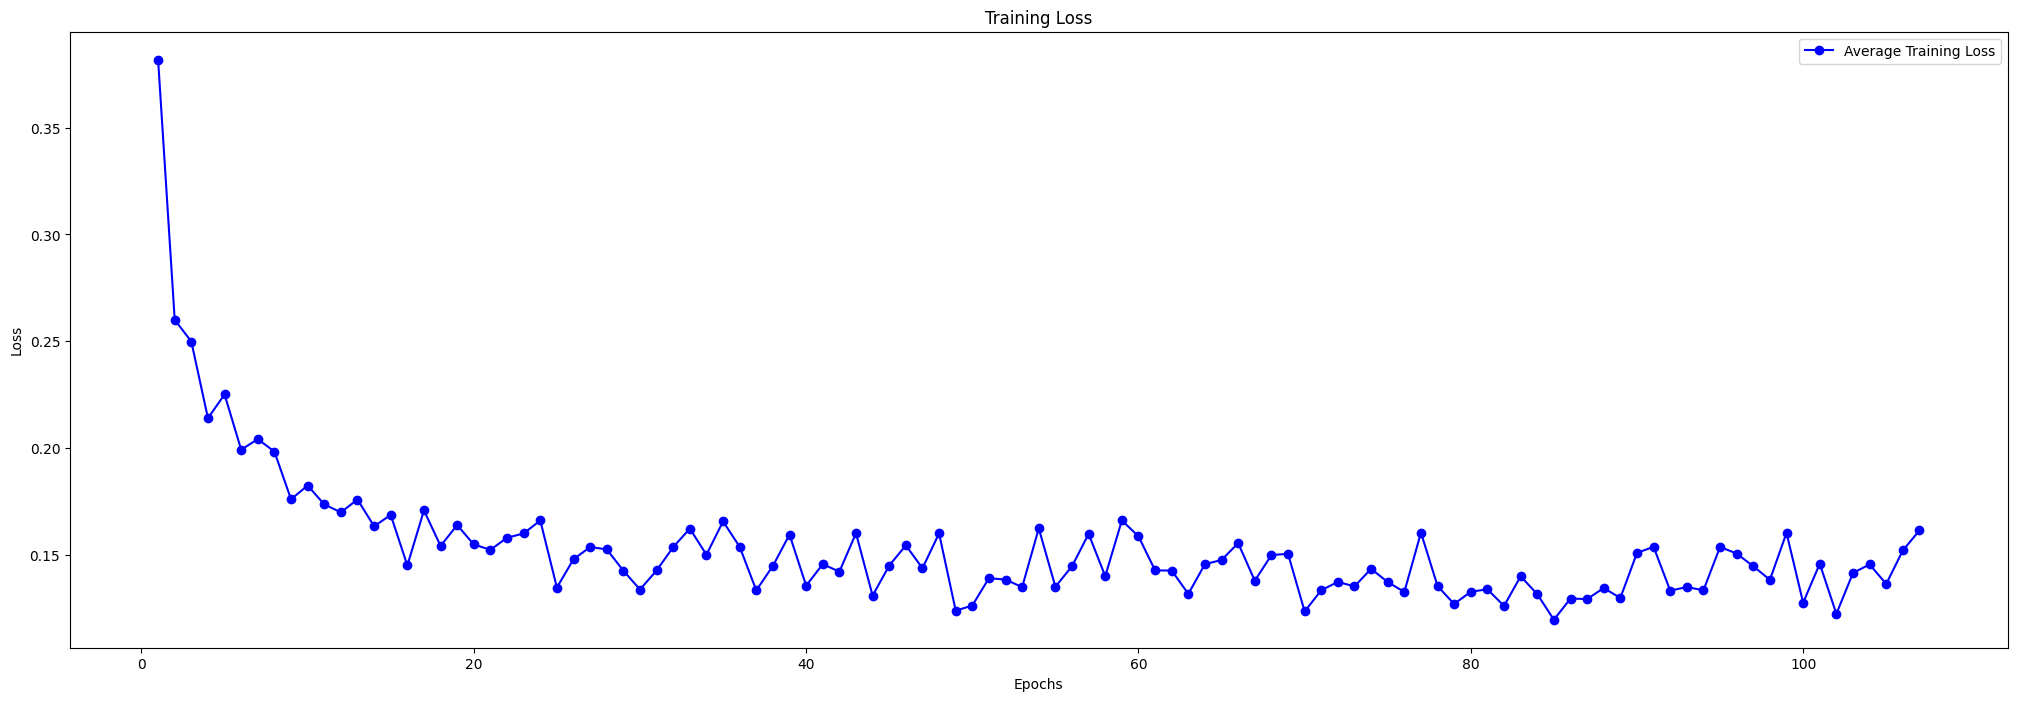

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 8))

# Plotting
plt.plot([(i+1) for i, avg_loss in enumerate(avg_losses)], [avg_loss for avg_loss in avg_losses], 'bo-', label='Average Training Loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
print(tokenizer.decode(tokenized_dataset[20000]))

<bos>SYSTEM: You are a helpful assistant with access to the following functions. Use them if required -
{
    "name": "calculate_mortgage_payment",
    "description": "Calculate the monthly mortgage payment",
    "parameters": {
        "type": "object",
        "properties": {
            "loan_amount": {
                "type": "number",
                "description": "The amount of the loan"
            },
            "interest_rate": {
                "type": "number",
                "description": "The annual interest rate on the loan"
            },
            "loan_term": {
                "type": "integer",
                "description": "The term of the loan in years"
            }
        },
        "required": [
            "loan_amount",
            "interest_rate",
            "loan_term"
        ]
    }
}

{
    "name": "search_books",
    "description": "Search for books based on specified criteria",
    "parameters": {
        "type": "object",
        "properties": {

In [ ]:
from transformers import GenerationConfig

input_text = """
<bos>SYSTEM: You are a helpful assistant with access to the following functions. Use them if required -
{
    "name": "calculate_bmi",
    "description": "Calculate the BMI (Body Mass Index)",
    "parameters": {
        "type": "object",
        "properties": {
            "weight": {
                "type": "number",
                "description": "The weight of the person in kilograms"
            },
            "height": {
                "type": "number",
                "description": "The height of the person in meters"
            }
        },
        "required": [
            "weight",
            "height"
        ]
    }
}


USER: Hi, I need to calculate my BMI. I weigh 70 kg and my height is 1.75 meters.
ASSISTANT:
"""
input_ids = tokenizer(input_text, return_tensors="pt").to(device)

outputs = pretrained_model.generate(
    **input_ids,
    generation_config=GenerationConfig.from_dict({"max_new_tokens": 1000}),
    stop_strings=["<|endoftext|>"],
    tokenizer=tokenizer,
).to(device)
print(tokenizer.decode(outputs[0]))

<bos>
<bos>SYSTEM: You are a helpful assistant with access to the following functions. Use them if required -
{
    "name": "calculate_bmi",
    "description": "Calculate the BMI (Body Mass Index)",
    "parameters": {
        "type": "object",
        "properties": {
            "weight": {
                "type": "number",
                "description": "The weight of the person in kilograms"
            },
            "height": {
                "type": "number",
                "description": "The height of the person in meters"
            }
        },
        "required": [
            "weight",
            "height"
        ]
    }
}


USER: Hi, I need to calculate my BMI. I weigh 70 kg and my height is 1.75 meters.
ASSISTANT:
<functioncall> {"name": "calculate_bmi", "arguments": '{"weight": 70, "height": 1.75}'} <|endoftext|>


In [ ]:
pretrained_model.save_pretrained('/content/gemma_function_model_exp3')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
!zip -r function_gemma_trained.zip '/content/gemma_function_model_exp3'

  adding: content/gemma_function_model_exp3/ (stored 0%)
  adding: content/gemma_function_model_exp3/generation_config.json (deflated 21%)
  adding: content/gemma_function_model_exp3/model.safetensors (deflated 21%)
  adding: content/gemma_function_model_exp3/config.json (deflated 67%)
